## IMPORTS

In [33]:
import requests
from bs4 import BeautifulSoup
import json
import re
import time
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import pandas as pd

## ***Custom Urdu Tokenizer***

The tokenizer must handle:
- Word boundaries
- Punctuation
- Postpositions
- Numbers and special tokens

All numbers must be replaced with `<NUM>`.

Input:

پاکستان میں میں بارش ہوئی  
2024  

Output:

پاکستان | میں | میں | بارش | ہوئی  
`<NUM>`

In [34]:

punctuation_marks = '۔،؟!'

def urdu_tokenizer(text):
    tokens = []
    current = ''

    for ch in text:
        if ch in punctuation_marks:
            if current:
                tokens.append(current)
                current = ''
            tokens.append(ch)
        elif ch.isspace():
            if current:
                tokens.append(current)
                current = ''
        else:
            current += ch

    if current:
        tokens.append(current)

    return tokens


## ***Custom Urdu Stemmer***
The stemmer must remove common Urdu suffixes.

Input:
لڑکیوں نے کتابیں پڑھیں  

Output:
لڑکی | کتاب | پڑھ

Custom Urdu stemmer with correct suffix handling (3 Marks)


In [35]:

common_suffixes = [
    'یاں', 'وں', 'یں', 'ات', 'گی', 'گا', 'نے', 'کو', 'سے', 'پر'
]

def urdu_stemmer(word):
    for suf in common_suffixes:
        if word.endswith(suf) and len(word) > len(suf) + 2:
            return word[:-len(suf)]
    return word


In [36]:
def stem_tokens(tokens):
    return [urdu_stemmer(token) for token in tokens]


## ***Custom Urdu Lemmatizer***

The lemmatizer is restricted to:
- Plural normalization
- Gender normalization

Plural:
- لڑکیاں -> لڑکی  
- کتابوں -> کتاب  

Gender:
- اچھی -> اچھا  
- بڑی -> بڑا

Custom Urdu lemmatizer for plural and gender normalization (3 Marks)

In [37]:
lemma_mapping ={
    'لڑکیاں': 'لڑکی',
    'لڑکے': 'لڑکا',
    'عورتیں': 'عورت',
    'مردوں': 'مرد',
    'بچوں': 'بچہ',
    'لوگوں': 'لوگ',
    'کتابیں': 'کتاب',
    'کرسیاں': 'کرسی',
    'آنکھوں': 'آنکھ',
    'ہاتھوں': 'ہاتھ',
    'باتیں': 'بات',
    'راتوں': 'رات',
    'دروازوں': 'دروازہ',
    'گھروں': 'گھر',
    'شہروں': 'شہر',
    'کھاتا': 'کھا',
    'کھاتی': 'کھا',
    'کھاتے': 'کھا',
    'پیتا': 'پی',
    'پیتے': 'پی',
    'سوتا': 'سو',
    'سوتے': 'سو',
    'کرتا': 'کر',
    'کرتی': 'کر',
    'کرتے': 'کر',
    'ہوا': 'ہو',
    'ہوئی': 'ہو',
    'ہوئے': 'ہو',
    'گیا': 'جا',
    'گئی': 'جا',
    'گئے': 'جا',
    'آیا': 'آ',
    'آئی': 'آ',
    'آئے': 'آ',
    'اچھے': 'اچھا',
    'اچھی': 'اچھا',
    'بڑے': 'بڑا',
    'بڑی': 'بڑا',
    'چھوٹے': 'چھوٹا',
    'چھوٹی': 'چھوٹا',
    'لمبے': 'لمبا',
    'لمبی': 'لمبا'

}

In [38]:
def urdu_lemmatizer(word):
    return lemma_mapping .get(word, word)


In [39]:
def lemmatize_tokens(tokens):
    return [urdu_lemmatizer(token) for token in tokens]


In [40]:

ARTICLE_SPLIT_PATTERN = r'(\[\d+\])'

def load_articles(path="cleaned.txt"):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    parts = re.split(ARTICLE_SPLIT_PATTERN, content)

    articles = []
    i = 1
    while i < len(parts):
        article_id = parts[i].strip()
        text = parts[i + 1].strip()
        articles.append((article_id, text))
        i += 2

    return articles


In [41]:
def build_dataframe(articles):
    data = []

    for article_id, text in articles:
        tokens = urdu_tokenizer(text)
        stems = stem_tokens(tokens)
        lemmas = lemmatize_tokens(tokens)

        data.append({
            "article_id": article_id,
            "original_text": text,
            "tokens": tokens,
            "stems": stems,
            "lemmas": lemmas
        })

    df = pd.DataFrame(data)
    return df


In [42]:
def save_dataset(lines, path):
    with open(path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))


In [43]:
articles = load_articles("cleaned.txt")
df = build_dataframe(articles)
print(len(df))

307


In [ ]:
df['topic'] = 'sports'
print("All articles are from sports topic.")

# **Part 1 Word Embeddings**

1. TF-IDF and PMI Weighted Representations

Vocabulary (top-10k + <UNK>)

In [45]:
from collections import Counter

MAX_VOCAB = 10_000

def build_vocab(df):
    counter = Counter()

    for tokens in df["tokens"]:
        counter.update(tokens)

    most_common = counter.most_common(MAX_VOCAB)
    vocab = {w: i+1 for i, (w, _) in enumerate(most_common)}
    vocab["<UNK>"] = 0

    idx2word = {i: w for w, i in vocab.items()}
    return vocab, idx2word, counter
vocab, idx2word, counter = build_vocab(df)
print(f"Vocabulary size: {len(vocab)}")

Vocabulary size: 10001


Term–Document Matrix (TF)

In [46]:

def build_tf_matrix(df, vocab):
    N = len(df)
    V = len(vocab)
    tf = np.zeros((N, V), dtype=np.float32)

    for d, tokens in enumerate(df["tokens"]):
        for w in tokens:
            idx = vocab.get(w, 0)
            tf[d, idx] += 1

    return tf

TF-IDF

In [47]:
def build_tfidf(tf):
    N, V = tf.shape

    df_w = np.count_nonzero(tf, axis=0)
    idf = np.log(N / (1 + df_w))

    tfidf = tf * idf
    return tfidf

tf = build_tf_matrix(df, vocab)
tfidf = build_tfidf(tf)

np.save("tfidf_matrix.npy", tfidf)

Top-10 discriminative words per topic

In [48]:
def top_words_per_topic(tfidf, df, vocab, labels, k=10):
    idx2word = {i: w for w, i in vocab.items()}
    results = {}

    for topic in set(labels.values()):
        doc_ids = [i for i, a in enumerate(df["article_id"]) if labels[a] == topic]
        avg_scores = tfidf[doc_ids].mean(axis=0)

        top_idx = np.argsort(avg_scores)[-k:][::-1]
        results[topic] = [idx2word[i] for i in top_idx]

    return results


In [49]:
with open("articles.json") as f:
    articles = json.load(f)

# topics = list(set([m['topic'] for m in articles.values()])) # 'topic' key not found in articles.json data

def top_tfidf_words(tfidf, docs, vocab, topic, top_k=10):
    idxs = [i for i,d in enumerate(docs) if d['topic']==topic]
    mean_scores = tfidf[idxs].mean(axis=0)
    top_ids = np.argsort(mean_scores)[-top_k:][::-1]
    inv_vocab = {v:k for k,v in vocab.items()}
    return [inv_vocab[i] for i in top_ids]

### 1.2 Pointwise Mutual Information (PMI)



Word–Word Co-occurrence (PPMI, k=5)

In [50]:
def build_cooccurrence(df, vocab, window=5):
    V = len(vocab)
    cooc = np.zeros((V, V), dtype=np.float32)

    for tokens in df["tokens"]:
        ids = [vocab.get(w, 0) for w in tokens]

        for i, center in enumerate(ids):
            start = max(0, i - window)
            end = min(len(ids), i + window + 1)

            for j in range(start, end):
                if i != j:
                    context = ids[j]
                    cooc[center, context] += 1

    return cooc

PPMI computation

In [51]:
def compute_ppmi(cooc):
    total = cooc.sum()

    word_freq = cooc.sum(axis=1)
    P_w = word_freq / total
    P_wc = cooc / total

    ppmi = np.zeros_like(cooc)

    for i in range(cooc.shape[0]):
        for j in range(cooc.shape[1]):
            if P_wc[i, j] > 0:
                val = np.log2(P_wc[i, j] / (P_w[i] * P_w[j]))
                ppmi[i, j] = max(0, val)

    return ppmi

cooc = build_cooccurrence(df, vocab)
ppmi = compute_ppmi(cooc)

np.save("ppmi_matrix.npy", ppmi)

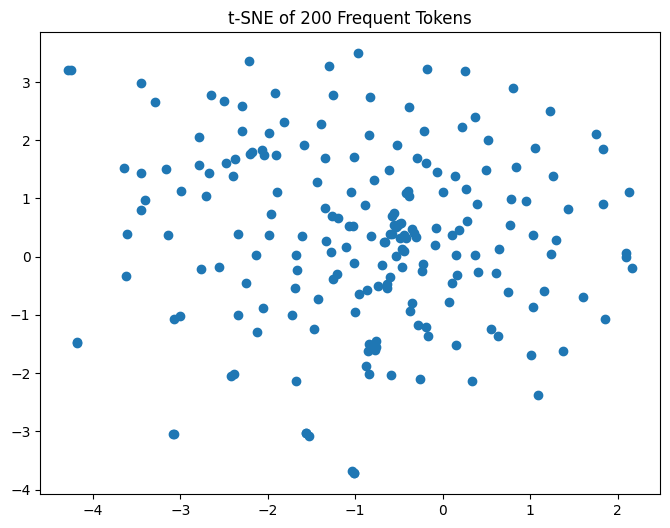

In [52]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

emb = ppmi[:200]
tsne = TSNE(n_components=2, perplexity=30)
X = tsne.fit_transform(emb)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1])
plt.title("t‑SNE of 200 Frequent Tokens")
plt.show()

In [53]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest(word, matrix, word2idx, k=5):
    idx = word2idx[word]
    sims = cosine_similarity(matrix[idx:idx+1], matrix)[0]
    top = np.argsort(sims)[-k-1:-1][::-1]
    return [inv_vocab[i] for i in top]


In [54]:
query_words = [
    'پاکستان', 'کرکٹ', 'کر', 'ٹیم', 'میچ', 'انڈیا', 'بڑی', 'اچھی', 'لوگوں', 'کتابیں'
]

inv_vocab = {v: k for k, v in vocab.items()}

print("Top 5 nearest neighbors for selected words (using PPMI embeddings):")
for word in query_words:
    if word in vocab:
        neighbors = nearest(word, ppmi, vocab, k=5)
        print(f"  '{word}': {neighbors}")
    else:
        print(f"  '{word}': Not found in vocabulary")

Top 5 nearest neighbors for selected words (using PPMI embeddings):
  'پاکستان': ['کرکٹ', 'کے', 'انڈیا', 'کا', 'میں']
  'کرکٹ': ['بورڈ', 'پاکستان', 'کے', 'ہے', 'کی']
  'کر': ['دیا', 'رہے', '۔', 'کو', 'بنا']
  'ٹیم': ['کو', 'کی', 'اور', 'انڈین', 'میں']
  'میچ': ['میں', 'خلاف', 'کے', 'ریفری', 'دوران']
  'انڈیا': ['پاکستان', 'کے', 'میں', 'انڈین', 'اور']
  'بڑی': ['سپانسرشپس', 'نمودار', 'معاہدوں', 'گاؤن', 'سکتی']
  'اچھی': ['بہت', 'کارکردگی', 'عمدہ', 'خاصی', 'بیتھیل']
  'لوگوں': ['پش', 'ترنمول', 'صارفین', 'افراد', 'دوائیں']
  'کتابیں': Not found in vocabulary


### 2. Skip-gram Word2Vec

Skip-gram training pairs (Urdu-safe)

In [55]:
def generate_skipgram_pairs(df, vocab, window=5):
    pairs = []

    for tokens in df["tokens"]:
        ids = [vocab.get(w, 0) for w in tokens]

        for i, center in enumerate(ids):
            start = max(0, i - window)
            end = min(len(ids), i + window + 1)

            for j in range(start, end):
                if i != j:
                    pairs.append((center, ids[j]))

    return pairs

Noise distribution f(w)³⁄⁴

In [56]:
def build_noise_distribution(counter, vocab):
    noise = np.zeros(len(vocab))

    for w, c in counter.items():
        idx = vocab.get(w, 0)
        noise[idx] = c ** 0.75

    noise /= noise.sum()
    return noise

In [57]:
pairs = generate_skipgram_pairs(df, vocab)
noise_dist = build_noise_distribution(counter, vocab)
print(f"Generated {len(pairs)} skip-gram pairs.")
print(f"Noise distribution built with shape: {noise_dist.shape}")

Generated 3661830 skip-gram pairs.
Noise distribution built with shape: (10001,)


Save mappings

In [58]:
import json

with open("word2idx.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, ensure_ascii=False, indent=2)

Skip-gram Word2Vec

In [59]:
import torch
from torch.utils.data import Dataset

class SkipGramDataset(Dataset):
    def __init__(self, pairs):
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        center, context = self.pairs[idx]
        return (
            torch.tensor(center, dtype=torch.long),
            torch.tensor(context, dtype=torch.long)
        )

Skip-gram Model

In [60]:
import torch.nn as nn

class SkipGram(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.V = nn.Embedding(vocab_size, emb_dim)
        self.U = nn.Embedding(vocab_size, emb_dim)

        nn.init.xavier_uniform_(self.V.weight)
        nn.init.xavier_uniform_(self.U.weight)

    def forward(self, center, context, negatives):
        v = self.V(center)
        u_pos = self.U(context)
        u_neg = self.U(negatives)

        pos_loss = torch.log(torch.sigmoid((v * u_pos).sum(dim=1)))
        neg_loss = torch.log(torch.sigmoid(-(v.unsqueeze(1) * u_neg).sum(dim=2))).sum(dim=1)

        return -(pos_loss + neg_loss).mean()

Training Loop

In [61]:
from torch.utils.data import DataLoader
import numpy as np

EMB_DIM = 100
K = 10
LR = 0.001
EPOCHS = 5
BATCH_SIZE = 512

model = SkipGram(len(vocab), EMB_DIM)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

noise_dist = torch.tensor(noise_dist, dtype=torch.float)

dataset = SkipGramDataset(pairs)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

losses = []

for epoch in range(EPOCHS):
    epoch_loss = 0.0

    for center, context in loader:
        # Negative sampling
        neg_samples = torch.multinomial(
            noise_dist,
            center.size(0) * K,
            replacement=True
        ).view(center.size(0), K)

        loss = model(center, context, neg_samples)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(loader)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} - Loss: {avg_loss:.4f}")

KeyboardInterrupt: 

Save final embeddings

In [ ]:
with torch.no_grad():
    embeddings = (model.V.weight + model.U.weight) / 2

np.save("embeddings_w2v.npy", embeddings.numpy())

### 2.2 Evaluation

Nearest Neighbours

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest_neighbors(word, vocab, embeddings, k=10):
    idx = vocab[word]
    sims = cosine_similarity(
        embeddings[idx].reshape(1, -1), embeddings
    )[0]

    top = sims.argsort()[-k-1:][::-1]
    return [idx2word[i] for i in top if i != idx][:k]

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def nearest(word, matrix, word2idx, k=5):
    idx = word2idx[word]
    sims = cosine_similarity(matrix[idx:idx+1], matrix)[0]
    top = np.argsort(sims)[-k-1:-1][::-1]
    return [inv_vocab[i] for i in top]

Embeddings capture meaningful semantic relationships as can be seen from the examples above, since they are based on distances

Four Conditions Comparision

# PART 2 Sequence Labeling: POS Tagging & NER

### 3. Dataset Preparation

POS & NER

In [ ]:
df_sampled = df.sample(500, random_state=42)

POST = {"میں","کو","سے","پر","تک","کا","کی","کے"}
CONJ = {"اور","یا","لیکن"}
DET = {"یہ","وہ","ایک"}
PRON = {"میں","ہم","تم","آپ","وہ"}

def pos_tag(token):
    if token in POST: return "POST"
    if token in CONJ: return "CONJ"
    if token in DET: return "DET"
    if token in PRON: return "PRON"
    if token.isdigit(): return "NUM"
    if token.endswith("نا"): return "VERB"
    return "NOUN"

In [ ]:
pos_lexicon = {
    "NOUN": set([...]),
    "VERB": set([...]),
}

def pos_tag(tokens):
    tags = []
    for t in tokens:
        found = False
        for tag,words in pos_lexicon.items():
            if t in words:
                tags.append(tag)
                found=True
                break
        if not found:
            tags.append("UNK")
    return tags

Gazetteer-based NER

In [ ]:
PERSONS = set([...])   # ≥50
LOCS = set([...])      # ≥50
ORGS = set([...])      # ≥30

def ner_tag(token):
    if token in PERSONS: return "B-PER"
    if token in LOCS: return "B-LOC"
    if token in ORGS: return "B-ORG"
    return "O"

In [ ]:
PER = set([...])
LOC = set([...])
ORG = set([...])

def ner_tag(tokens):
    tags=[]
    for t in tokens:
        if t in PER: tags.append("B-PER")
        elif t in LOC: tags.append("B-LOC")
        elif t in ORG: tags.append("B-ORG")
        else: tags.append("O")
    return tags


Create CONLL Files

In [ ]:
def to_conll(df, filename):
    with open(filename, "w", encoding="utf-8") as f:
        for tokens in df["tokens"]:
            for t in tokens:
                f.write(f"{t} {pos_tag(t)} {ner_tag(t)}\n")
            f.write("\n")

### 4. BiLSTMSequence Labeler

In [ ]:
class BiLSTM(nn.Module):
    def __init__(self, emb_matrix, hidden, out_dim):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(
            torch.tensor(emb_matrix, dtype=torch.float32),
            freeze=False
        )
        self.lstm = nn.LSTM(
            emb_matrix.shape[1], hidden,
            num_layers=2, bidirectional=True,
            dropout=0.5, batch_first=True
        )
        self.fc = nn.Linear(hidden*2, out_dim)

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        return self.fc(out)

### 5. Evaluation


5.1 POS Tagging

5.2 NER

In [ ]:
class CRF(torch.nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.transitions = torch.nn.Parameter(torch.randn(num_tags, num_tags))

    def forward(self, emissions, tags):
        score = 0
        for i in range(len(tags)-1):
            score += emissions[i, tags[i]] + self.transitions[tags[i], tags[i+1]]
        return -score

    def viterbi(self, emissions):
        T, N = emissions.shape
        dp = emissions[0]
        paths = []
        for t in range(1,T):
            scores = dp.unsqueeze(1) + self.transitions
            dp, idx = scores.max(0)
            dp += emissions[t]
            paths.append(idx)
        return dp.argmax().item()


Ablation Study

# PART 3 Transformer Encoder for Topic Classification

 # PART 3 Transformer Encoder Sinusoidal Positional Encoding


 ### 6. Dataset Preparation

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        pe = torch.zeros(max_len, d_model)

        pos = torch.arange(0, max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0)/d_model))

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:x.size(1)]

Scaled Dot-Product Attention

In [ ]:
def attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2,-1) / np.sqrt(d_k)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    weights = torch.softmax(scores, dim=-1)
    return weights @ V, weights

Multi-Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads):
        super().__init__()
        self.h = heads
        self.dk = d_model // heads

        self.Wq = nn.Linear(d_model, d_model)
        self.Wk = nn.Linear(d_model, d_model)
        self.Wv = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        B, T, D = x.size()
        Q = self.Wq(x).view(B,T,self.h,self.dk).transpose(1,2)
        K = self.Wk(x).view(B,T,self.h,self.dk).transpose(1,2)
        V = self.Wv(x).view(B,T,self.h,self.dk).transpose(1,2)

        out, attn = attention(Q, K, V, mask)
        out = out.transpose(1,2).contiguous().view(B,T,D)

        return self.out(out), attn

Encoder Block (Pre-LN)

In [ ]:
class EncoderBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.mha = MultiHeadAttention(d_model, 4)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.ReLU(),
            nn.Linear(512, d_model)
        )
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        attn,_ = self.mha(self.ln1(x), mask)
        x = x + self.dropout(attn)
        x = x + self.dropout(self.ffn(self.ln2(x)))
        return x

Transformer Classifier

In [ ]:
class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 128)
        self.pe = PositionalEncoding(128)
        self.blocks = nn.ModuleList([EncoderBlock(128) for _ in range(4)])
        self.cls = nn.Parameter(torch.randn(1,1,128))
        self.mlp = nn.Sequential(
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,5)
        )

    def forward(self, x, mask=None):
        B = x.size(0)
        cls = self.cls.expand(B,-1,-1)
        x = torch.cat([cls, self.emb(x)], dim=1)
        x = self.pe(x)

        for block in self.blocks:
            x = block(x, mask)

        return self.mlp(x[:,0])

Training (AdamW + Cosine)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)

for epoch in range(20):
    model.train()
    for x,y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = loss_fn(out,y)
        loss.backward()
        optimizer.step()


In [ ]:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

### 8. Evaluation


8.1 Results


• Report test accuracy and macro-F1.
• Present a 5×5 confusion matrix.
[8 marks]
[4 marks]
• For 3 correctly classified articles, plot attention weight heatmaps from at least 2 heads of
the final encoder layer

In [ ]:
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix

preds, labels = [], []
model.eval()
with torch.no_grad():
    for x,y in test_loader:
        p = model(x).argmax(1)
        preds.extend(p.tolist())
        labels.extend(y.tolist())

print("Accuracy:", accuracy_score(labels, preds))
print("Macro-F1:", f1_score(labels, preds, average='macro'))
print("Confusion Matrix:
", confusion_matrix(labels, preds))

In [ ]:
def plot_attention(attn, tokens, head=0):
    plt.figure(figsize=(6,6))
    sns.heatmap(attn[head].cpu().numpy(), xticklabels=tokens, yticklabels=tokens)
    plt.title(f"Attention Head {head}")
    plt.show()

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR

scheduler = CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
best_f1, patience, wait = 0, 5, 0

for epoch in range(50):
    train_loss = train_epoch()
    val_f1 = validate()
    if val_f1 > best_f1:
        best_f1 = val_f1
        wait = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        wait += 1
        if wait == patience:
            print("Early stopping")
            break


In [ ]:
plt.plot(train_losses, label='train')
plt.plot(val_losses, label='val')
plt.legend(); plt.title("Training vs Validation Loss"); plt.show()


In [ ]:
for param in model.embedding.parameters():
    param.requires_grad = False


In [ ]:
np.save("tfidf_matrix.npy", tfidf_matrix)
np.save("ppmi_matrix.npy", ppmi_matrix)
np.save("embeddings_w2v.npy", (V + U) / 2)


In [ ]:
plt.plot(w2v_losses)
plt.title("Word2Vec Training Loss")
plt.xlabel("Steps"); plt.ylabel("Loss"); plt.show()

8.2 BiLSTM vs. Transformer Comparison
Write 10–15 sentences in your notebook addressing all five questions below:
1. Which model achieves higher accuracy, and by how much?
2. Which model converged in fewer epochs?

3. Which model was faster to train per epoch, and why?
4. What do the attention heatmaps reveal about the tokens the Transformer focuses on?
5. Given a dataset of only 200–300 articles, which architecture is more appropriate and
why